# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv

In [2]:
coyote_results_file = "coyote_results.csv"
rl_results_file = "results_RL_agent_dynamic_llm_data.csv"
constrained_rl_results_file = "results_RL_agent_lppo_12716979.csv"
constrained_rl_with_linear_noise_estimator_results_file = "results_RL_agent_lppo_13739880.csv"

In [3]:
constrained_rl_ablation_od_ov_file = "test_lppo_ablation0_od_ov.xlsx"
constrained_rl_ablation_od_ov_with_linear_noise_estimator_file = "test_lppo_linear_noise_estimator.xlsx"
constrained_rl_ablation_ov_file = "test_lppo_ablation1_-od_ov.xlsx"
constrained_rl_ablation_od_file = "test_lppo_ablation2_od_-ov.xlsx"
constrained_rl_ablation_file = "test_lppo_ablation3_-od_-ov.xlsx"
rl_ablation_file = "test_ppo.xlsx"

In [4]:
benchmarks = [
    "Box Blur 3 × 3", "Box Blur 4 × 4","Box Blur 5 × 5",
    "Dot Product 4",  "Dot Product 8","Dot Product 16", "Dot Product 32",
    "Hamm. Dist. 4",  "Hamm. Dist. 8","Hamm. Dist. 16",  "Hamm. Dist. 32",
    "L2 Distance 4",  "L2 Distance 8","L2 Distance 16",  "L2 Distance 32",
    "Linear Reg. 4",  "Linear Reg. 8","Linear Reg. 16", "Linear Reg. 32",
    "Poly. Reg. 4", "Poly. Reg. 8", "Poly. Reg. 16",  "Poly. Reg. 32",
    "Gx 3 × 3", "Gx 4 × 4", "Gx 5 × 5",
    "Mat. Mul. 3 × 3", "Mat. Mul. 4 × 4",
    "Max 3","Max 4","Max 5",
    "Sort 3","Sort 4",
    "Tree 50-50-5", "Tree 50-50-10", "Tree 100-50-5", "Tree 100-100-5"
]

In [5]:
chehab_benchmarks_map = {
    "Box Blur 3 × 3" : "box_blur_3", "Box Blur 4 × 4" : "box_blur_4", "Box Blur 5 × 5" : "box_blur_5",

    "Dot Product 3" : "dot_product_3", "Dot Product 4" : "dot_product_4", "Dot Product 5" : "dot_product_5",
    "Dot Product 8" : "dot_product_8", "Dot Product 16" : "dot_product_16", "Dot Product 25" : "dot_product_25",
    "Dot Product 32" : "dot_product_32",

    "Hamm. Dist. 3" : "hamming_dist_3", "Hamm. Dist. 4" : "hamming_dist_4" , "Hamm. Dist. 5" : "hamming_dist_5" ,
    "Hamm. Dist. 8" : "hamming_dist_8", "Hamm. Dist. 16" : "hamming_dist_16" , "Hamm. Dist. 25" : "hamming_dist_25",
    "Hamm. Dist. 32" : "hamming_dist_32",

    "L2 Distance 3" : "l2_distance_3", "L2 Distance 4" : "l2_distance_4" , "L2 Distance 5" : "l2_distance_5" ,
    "L2 Distance 8" : "l2_distance_8", "L2 Distance 16" : "l2_distance_16" , "L2 Distance 25" : "l2_distance_25",
    "L2 Distance 32" : "l2_distance_32",

    "Linear Reg. 3" : "lin_reg_3", "Linear Reg. 4" : "lin_reg_4", "Linear Reg. 5" : "lin_reg_5",
    "Linear Reg. 8" : "lin_reg_8", "Linear Reg. 16" : "lin_reg_16"  , "Linear Reg. 25" : "lin_reg_25",
    "Linear Reg. 32" : "lin_reg_32",

    "Poly. Reg. 3" : "poly_reg_3", "Poly. Reg. 4" : "poly_reg_4", "Poly. Reg. 5" : "poly_reg_5",
    "Poly. Reg. 8" : "poly_reg_8", "Poly. Reg. 16" : "poly_reg_16", "Poly. Reg. 25" : "poly_reg_25",
    "Poly. Reg. 32" : "poly_reg_32",

    "Gx 3 × 3" : "gx_kernel_3", "Gx 4 × 4" : "gx_kernel_4", "Gx 5 × 5" : "gx_kernel_5",

    "Gy 3 × 3" : "gy_kernel_3", "Gy 4 × 4" : "gy_kernel_4", "Gy 5 × 5" : "gy_kernel_5",

    "Rob. Cross 3 × 3" : "roberts_cross_3", "Rob. Cross 4 × 4" : "roberts_cross_4", "Rob. Cross 5 × 5" : "roberts_cross_5",

    "Mat. Mul. 3 × 3" : "matrix_mul_3", "Mat. Mul. 4 × 4" : "matrix_mul_4", "Mat. Mul. 5 × 5" : "matrix_mul_5",

    "Sort 3" : "sort_3", "Sort 4" : "sort_4",

    "Max 5" : "max_5", "Max 4" : "max_4", "Max 3" : "max_3",

    "Tree 50-50-5": "tree_50-50_5_1",
    "Tree 50-50-10": "tree_50-50_10_1",
    "Tree 100-50-5": "tree_100-50_5_1",
    "Tree 100-50-10": "tree_100-50_10_1",
    "Tree 100-100-5": "tree_100-100_5_1",
    "Tree 100-100-10": "tree_100-100_10_1"
}

In [6]:
coyote_benchmarks_map = {
    "Dot Product 4" : "dot_product_4x4_fully", 
    "Dot Product 8"  : "dot_product_8x8_fully",
    "Dot Product 16" : "dot_product_16x16_fully", 
    "Dot Product 32" : "dot_product_32x32_fully",

    "Hamm. Dist. 4" : "hamming_distance_4", "Hamm. Dist. 3"  : "hamming_distance_3",
    "Hamm. Dist. 5"  : "hamming_distance_5", "Hamm. Dist. 8"  : "hamming_distance_8",
    "Hamm. Dist. 16" : "hamming_distance_16","Hamm. Dist. 25" : "hamming_distance_25",
    "Hamm. Dist. 32" : "hamming_distance_32",

    "L2 Distance 4" : "l2_distance_4" , "L2 Distance 3"  : "l2_distance_3",
    "L2 Distance 5"  : "l2_distance_5", "L2 Distance 8"  : "l2_distance_8",
    "L2 Distance 16" : "l2_distance_16", "L2 Distance 25" : "l2_distance_25",
    "L2 Distance 32" : "l2_distance_32",

    "Linear Reg. 4" : "linear_reg_4", "Linear Reg. 3"  : "linear_reg_3",
    "Linear Reg. 5"  : "linear_reg_5", "Linear Reg. 8"  : "linear_reg_8",
    "Linear Reg. 16" : "linear_reg_16","Linear Reg. 25" : "linear_reg_25",
    "Linear Reg. 32" : "linear_reg_32",

    "Poly. Reg. 4" : "poly_reg_4", "Poly. Reg. 3"  : "poly_reg_3",
    "Poly. Reg. 5"  : "poly_reg_5","Poly. Reg. 8"  : "poly_reg_8",
    "Poly. Reg. 16" : "poly_reg_16","Poly. Reg. 25" : "poly_reg_25",
    "Poly. Reg. 32" : "poly_reg_32",

    "Box Blur 3 × 3" : "box_blur_3x3", "Box Blur 4 × 4" : "box_blur_4x4", "Box Blur 5 × 5" : "box_blur_5x5",

    "Gx 3 × 3" : "gx_kernel_3x3" , "Gx 4 × 4" : "gx_kernel_4x4" , "Gx 5 × 5" : "gx_kernel_5x5" ,

    "Gy 3 × 3" : "gy_kernel_3x3" , "Gy 4 × 4" : "gy_kernel_4x4" , "Gy 5 × 5" : "gy_kernel_5x5" ,

    "Rob. Cross 3 × 3" : "roberts_cross_3x3", "Rob. Cross 4 × 4" : "roberts_cross_4x4", "Rob. Cross 5 × 5" : "roberts_cross_5x5",

    "Mat. Mul. 3 × 3" : "matmul_3x3_fully", "Mat. Mul. 4 × 4" : "matmul_4x4_fully", "Mat. Mul. 5 × 5" : "matmul_5x5_fully",

    "Sort 3" : "sort_3_packed_fully", "Sort 4" : "sort_4_packed_fully",

    "Max 5" : "max_5_packed_fully","Max 4" : "max_4_packed_fully", "Max 3" : "max_3_packed_fully",
    "Tree 50-50-5":"tree_50-50-5","Tree 50-50-10":"tree_50-50-10",
    "Tree 100-50-5":"tree_100-50-5","Tree 100-50-10":"tree_100-50-10",
    "Tree 100-100-5":"tree_100-100-5","Tree 100-100-10":"tree_100-100-10"
}

# Plot Execution Times

In [7]:
def plot_execution_time_histogram(benchmarks, times, labels, colors, timeout_value=7200):
    """
    Plots a histogram of execution times across different metrics.

    Parameters:
    benchmarks (list): List of benchmark names.
    times (dict): Dictionary with metric names as keys and lists of execution times as values.
    labels (list): List of metric names.
    colors (list): List of colors for each metric.
    timeout_value (int): The maximum value (e.g., timeout limit).
    """

    num_benchmarks = len(benchmarks)
    x = np.arange(num_benchmarks)
    width = 0.3

    fig, ax = plt.subplots(figsize=(24, 3))
    hatch_color = (0.6, 0.6, 0.6, 1.0)
    linewidth = 4.0

    for i, label in enumerate(labels):
        adjusted_times = [timeout_value if t == float('inf') else min(t, timeout_value) for t in times[label]]
        hatch_patterns = ['//' if t == timeout_value and original_t == float('inf') else '' for t, original_t in zip(adjusted_times, times[label])]
        bars = ax.bar(x + i * width, adjusted_times, width, label=label, color=colors[i])
        for bar, hatch in zip(bars, hatch_patterns):
            if hatch:
                bar.set_hatch(hatch)
                bar._hatch_color = hatch_color
                bar._hatch_linewidth = linewidth

    # ax.set_title("Compiling Time Comparison")
    ax.set_xticks(x + width * (len(labels) / 2))
    ax.set_xticklabels(benchmarks, rotation=45, ha="right", fontsize=14)
    # ax.set_xlabel("Benchmarks", fontsize=16)
    ax.set_ylabel("Execution Time (s)", fontsize=16)

    bar = ax.bar(0, 0, color='none', hatch='//', edgecolor=hatch_color, label="N/A (Noise budget exhaustion)")
    bar._hatch_color = hatch_color
    bar._hatch_linewidth = linewidth

    ax.set_yscale("log")
    # ax.legend(fontsize=15)
    ax.legend(fontsize=15, loc="upper center", bbox_to_anchor=(0.30, 1.04), ncol=3)
    plt.xlim(-0.5, len(x) - 0.2)
    plt.ylim(0, 2*10**3)
    plt.grid(axis='y', linestyle="--", linewidth=0.5, which='major')

    plt.show()


## CRL vs RL

/tmp/ipykernel_12908/593532138.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2*10**3)


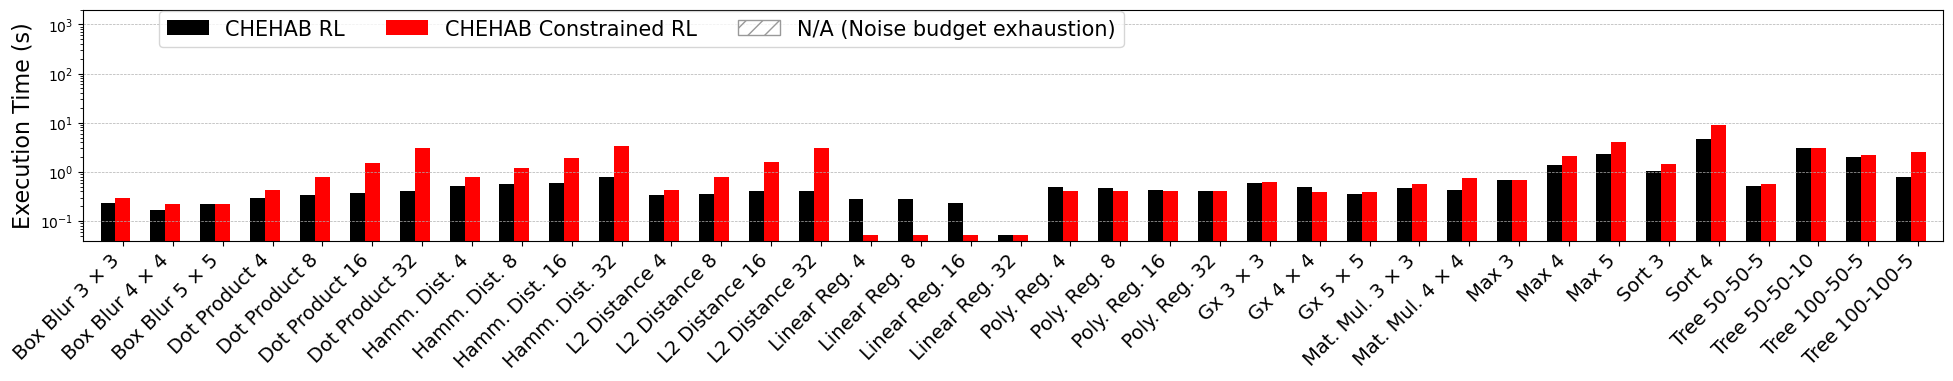

In [8]:
########################################################################################################
####################Load results #######################################################################
constrained_rl_rows = []
rl_rows = []
with open(constrained_rl_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    constrained_rl_rows = list(reader)
###########################################
with open(rl_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    rl_rows = list(reader)
#######################################################################################################
#######################################################################################################
constrained_rl_execution_times = []
rl_execution_times = []
for benchmark in benchmarks : 
    found = False
    for row in constrained_rl_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] :
            if len(row) > 1 :
                try : 
                    exec_time = float(row[10])
                except : 
                    exec_time = float('inf') 
                constrained_rl_execution_times.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        print("not found", benchmark)
        constrained_rl_execution_times.append(0)
    #####################################################
    found = False
    for row in rl_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] : 
            if len(row) > 1 :
                try : 
                    exec_time = float(row[10])
                except : 
                    exec_time = float('inf')
                rl_execution_times.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        rl_execution_times.append(0)

times = {
    "CHEHAB RL": np.array(rl_execution_times),
    "CHEHAB Constrained RL": np.array(constrained_rl_execution_times),
}
labels = ["CHEHAB RL", "CHEHAB Constrained RL"]
colors = ['Black', 'Red']
plot_execution_time_histogram(benchmarks, times, labels, colors)


## CRL vs Coyote

/tmp/ipykernel_12908/593532138.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2*10**3)


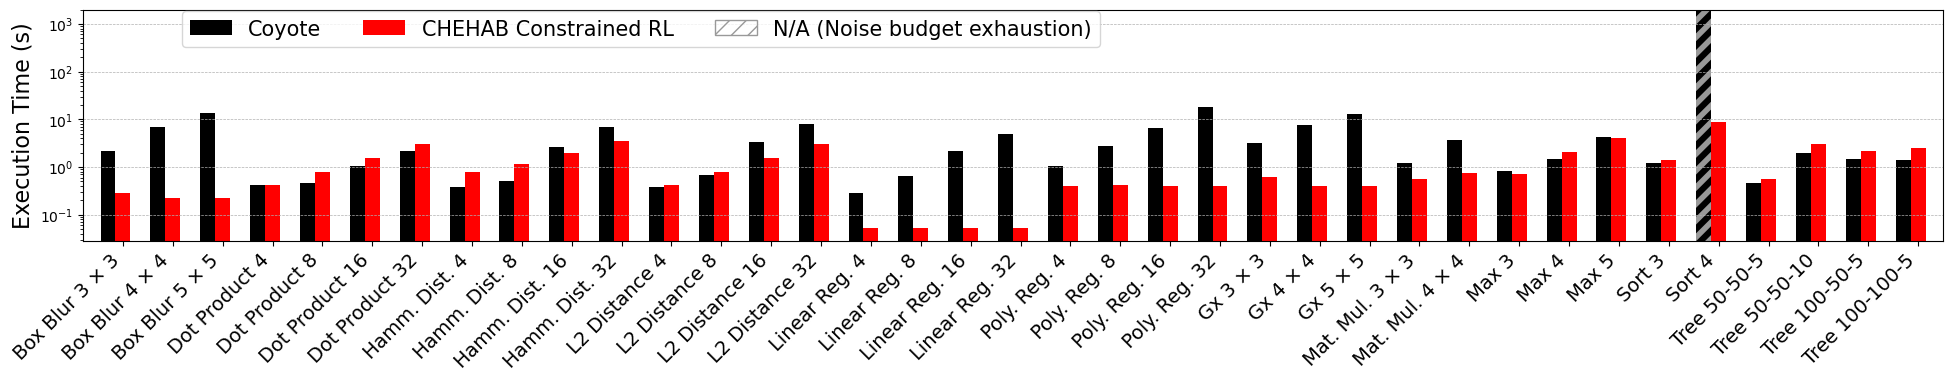

In [9]:
########################################################################################################
####################Load results #######################################################################
constrained_rl_rows = []
coyote_rows = []
with open(constrained_rl_results_file, mode='r', newline='') as infile:
     reader = csv.reader(infile)
     headers = next(reader)
     constrained_rl_rows = list(reader)
###########################################
with open(coyote_results_file, mode='r', newline='') as infile:
     reader = csv.reader(infile)
     headers = next(reader)
     coyote_rows = list(reader)
#######################################################################################################
#######################################################################################################
constrained_rl_execution_times = []
coyote_execution_times = []
for benchmark in benchmarks : 
     found = False
     for row in constrained_rl_rows :
          if row[0] ==  chehab_benchmarks_map[benchmark] :
               if len(row) > 1 :
                    try : 
                         exec_time = float(row[10])
                    except : 
                         exec_time = float('inf') 
                    constrained_rl_execution_times.append(exec_time)
                    found= True
                    break
               else : 
                    break
     if not found : 
          print("not found", benchmark)
          constrained_rl_execution_times.append(0)
     #####################################################
     found = False
     for row in coyote_rows :
          if row[0] ==  coyote_benchmarks_map[benchmark] : 
               if len(row) > 1 :
                    try : 
                         exec_time = float(row[9])
                    except : 
                         exec_time = float('inf')
                    coyote_execution_times.append(exec_time)
                    found= True
                    break
               else : 
                    break
     if not found : 
          coyote_execution_times.append(0)

times = {
    "Coyote": np.array(coyote_execution_times),
    "CHEHAB Constrained RL": np.array(constrained_rl_execution_times),
}
labels = ["Coyote", "CHEHAB Constrained RL"]
colors = ['Black', 'Red']
plot_execution_time_histogram(benchmarks, times, labels, colors)


# Plot Actual Noise Used

In [10]:
def plot_actual_noise_used_histogram(benchmarks, times, labels, colors, timeout_value=7200):
    """
    Plots a histogram comparing noise used across different metrics.

    Parameters:
    benchmarks (list): List of benchmark names.
    times (dict): Dictionary with metric names as keys and lists of noise used as values.
    labels (list): List of metric names.
    colors (list): List of colors for each metric.
    timeout_value (int): The maximum value (e.g., timeout limit).
    """

    num_benchmarks = len(benchmarks)
    x = np.arange(num_benchmarks)
    width = 0.3

    fig, ax = plt.subplots(figsize=(24, 3))
    hatch_color = (0.6, 0.6, 0.6, 1.0)
    linewidth = 4.0

    for i, label in enumerate(labels):
        adjusted_times = [timeout_value if t == float('inf') else min(t, timeout_value) for t in times[label]]
        hatch_patterns = ['//' if t == timeout_value and original_t == float('inf') else '' for t, original_t in zip(adjusted_times, times[label])]
        bars = ax.bar(x + i * width, adjusted_times, width, label=label, color=colors[i])
        for bar, hatch in zip(bars, hatch_patterns):
            if hatch:
                bar.set_hatch(hatch)
                bar._hatch_color = hatch_color
                bar._hatch_linewidth = linewidth

    # ax.set_title("Compiling Time Comparison")
    ax.set_xticks(x + width * (len(labels) / 2))
    ax.set_xticklabels(benchmarks, rotation=45, ha="right", fontsize=14)
    # ax.set_xlabel("Benchmarks", fontsize=16)
    ax.set_ylabel("Actual Noise Used", fontsize=12)

    bar._hatch_color = hatch_color
    bar._hatch_linewidth = linewidth

    #ax.set_yscale("log")
    # ax.legend(fontsize=15)
    ax.legend(fontsize=15, loc="upper center", bbox_to_anchor=(0.30, 1.04), ncol=3)
    plt.xlim(-0.5, len(x) - 0.2)
    plt.ylim(0, 369)
    plt.grid(axis='y', linestyle="--", linewidth=0.5, which='major')

    plt.show()


## CRL vs RL

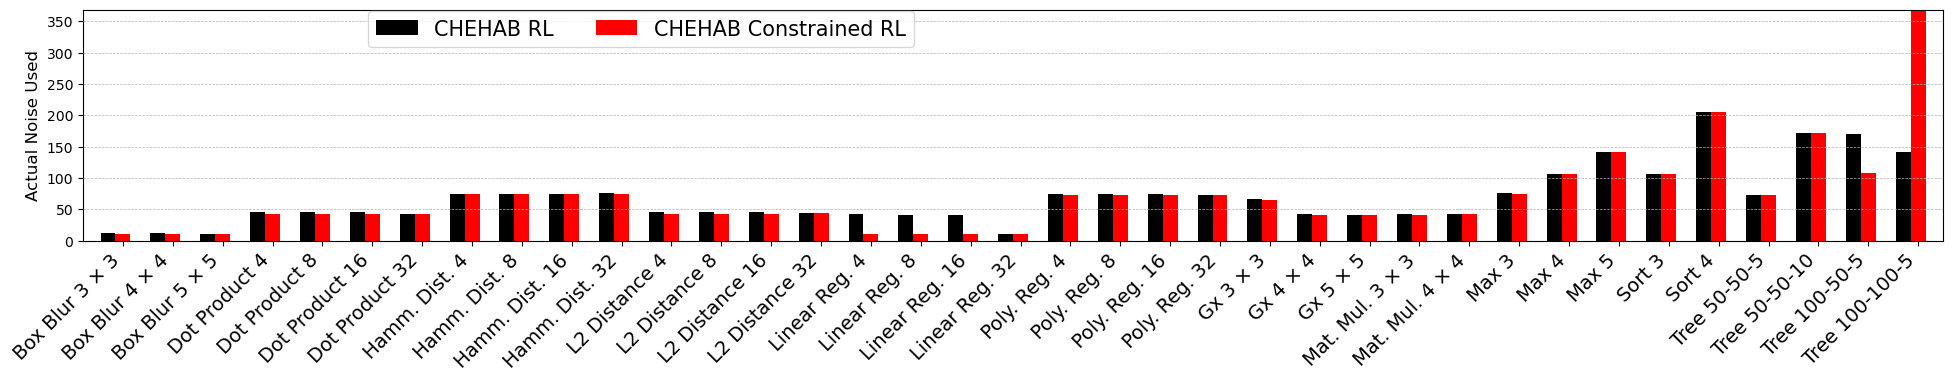

In [11]:
########################################################################################################
####################Load results #######################################################################
constrained_rl_rows = []
rl_rows = []
with open(constrained_rl_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    constrained_rl_rows = list(reader)
###########################################
with open(rl_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    rl_rows = list(reader)
#######################################################################################################
#######################################################################################################
constrained_rl_noises_used = []
rl_noises_used = []
for benchmark in benchmarks : 
    found = False
    for row in constrained_rl_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] :
            if len(row) > 1 :
                try : 
                    exec_time = 369 -  float(row[11])
                except : 
                    exec_time = float('inf') 
                constrained_rl_noises_used.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        print("not found", benchmark)
        constrained_rl_noises_used.append(0)
    #####################################################
    found = False
    for row in rl_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] : 
            if len(row) > 1 :
                try : 
                    exec_time = 369 - float(row[11])
                except : 
                    exec_time = float('inf')
                rl_noises_used.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        rl_noises_used.append(0)

times = {
    "CHEHAB RL": np.array(rl_noises_used),
    "CHEHAB Constrained RL": np.array(constrained_rl_noises_used),
}
labels = ["CHEHAB RL", "CHEHAB Constrained RL"]
colors = ['Black', 'Red']
plot_actual_noise_used_histogram(benchmarks, times, labels, colors)

## CRL vs Coyote

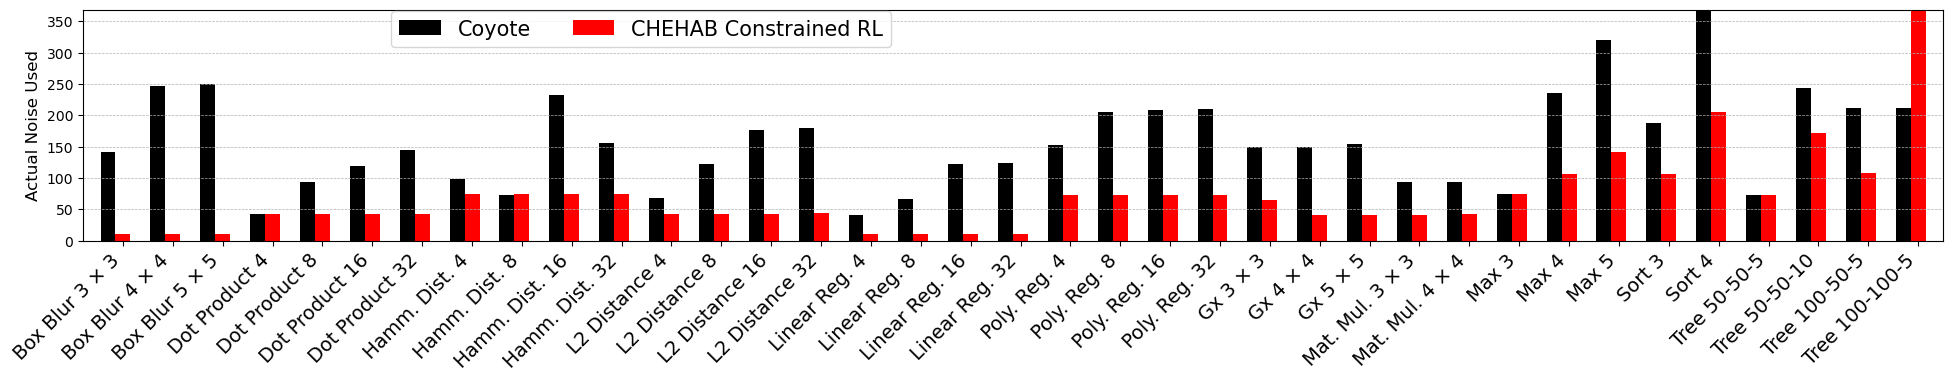

In [12]:
########################################################################################################
####################Load results #######################################################################
constrained_rl_rows = []
coyote_rows = []
with open(constrained_rl_results_file, mode='r', newline='') as infile:
     reader = csv.reader(infile)
     headers = next(reader)
     constrained_rl_rows = list(reader)
###########################################
with open(coyote_results_file, mode='r', newline='') as infile:
     reader = csv.reader(infile)
     headers = next(reader)
     coyote_rows = list(reader)
#######################################################################################################
#######################################################################################################
constrained_rl_noises_used = []
coyote_noises_used = []
for benchmark in benchmarks : 
     found = False
     for row in constrained_rl_rows :
          if row[0] ==  chehab_benchmarks_map[benchmark] :
               if len(row) > 1 :
                    try : 
                         exec_time = 369 -  float(row[11])
                    except : 
                         exec_time = float('inf') 
                    constrained_rl_noises_used.append(exec_time)
                    found= True
                    break
               else : 
                    break
     if not found : 
          print("not found", benchmark)
          constrained_rl_noises_used.append(0)
     #####################################################
     found = False
     for row in coyote_rows :
          if row[0] ==  coyote_benchmarks_map[benchmark] : 
               if len(row) > 1 :
                    try : 
                         exec_time = 369 - float(row[10])
                    except : 
                         exec_time = float('inf')
                    coyote_noises_used.append(exec_time)
                    found= True
                    break
               else : 
                    break
     if not found : 
          coyote_noises_used.append(0)

times = {
    "Coyote": np.array(coyote_noises_used),
    "CHEHAB Constrained RL": np.array(constrained_rl_noises_used),
}
labels = ["Coyote", "CHEHAB Constrained RL"]
colors = ['Black', 'Red']
plot_actual_noise_used_histogram(benchmarks, times, labels, colors)

# Plot Estimated Noise Used

In [13]:
def plot_estimated_noise_used_histogram(benchmarks, times, labels, colors, timeout_value=7200):
    """
    Plots a histogram comparing noise used across different metrics.

    Parameters:
    benchmarks (list): List of benchmark names.
    times (dict): Dictionary with metric names as keys and lists of noise used as values.
    labels (list): List of metric names.
    colors (list): List of colors for each metric.
    timeout_value (int): The maximum value (e.g., timeout limit).
    """

    num_benchmarks = len(benchmarks)
    x = np.arange(num_benchmarks)
    width = 0.3

    fig, ax = plt.subplots(figsize=(24, 3))
    hatch_color = (0.6, 0.6, 0.6, 1.0)
    linewidth = 4.0

    for i, label in enumerate(labels):
        adjusted_times = [timeout_value if t == float('inf') else min(t, timeout_value) for t in times[label]]
        hatch_patterns = ['//' if t == timeout_value and original_t == float('inf') else '' for t, original_t in zip(adjusted_times, times[label])]
        bars = ax.bar(x + i * width, adjusted_times, width, label=label, color=colors[i])
        for bar, hatch in zip(bars, hatch_patterns):
            if hatch:
                bar.set_hatch(hatch)
                bar._hatch_color = hatch_color
                bar._hatch_linewidth = linewidth

    # ax.set_title("Compiling Time Comparison")
    ax.set_xticks(x + width * (len(labels) / 2))
    ax.set_xticklabels(benchmarks, rotation=45, ha="right", fontsize=14)
    # ax.set_xlabel("Benchmarks", fontsize=16)
    ax.set_ylabel("Estimated Noise Used", fontsize=12)

    bar._hatch_color = hatch_color
    bar._hatch_linewidth = linewidth

    #ax.set_yscale("log")
    # ax.legend(fontsize=15)
    ax.legend(fontsize=15, loc="upper center", bbox_to_anchor=(0.30, 1.04), ncol=3)
    plt.xlim(-0.5, len(x) - 0.2)
    plt.ylim(0, 300)
    plt.grid(axis='y', linestyle="--", linewidth=0.5, which='major')

    plt.show()


In [14]:
constrained_rl_estimated_noises_used = pd.read_excel(constrained_rl_ablation_od_ov_file)
rl_estimated_noises_used = pd.read_excel(rl_ablation_file)

constrained_rl_name_to_estimated_noise_used = dict(zip(
    constrained_rl_estimated_noises_used["Name"].to_numpy(), 
    constrained_rl_estimated_noises_used["Final Noise Used"].to_numpy(),
))

rl_name_to_estimated_noise_used = dict(zip(
    rl_estimated_noises_used["Name"].to_numpy(), 
    rl_estimated_noises_used["Final Noise Used"].to_numpy(),
))

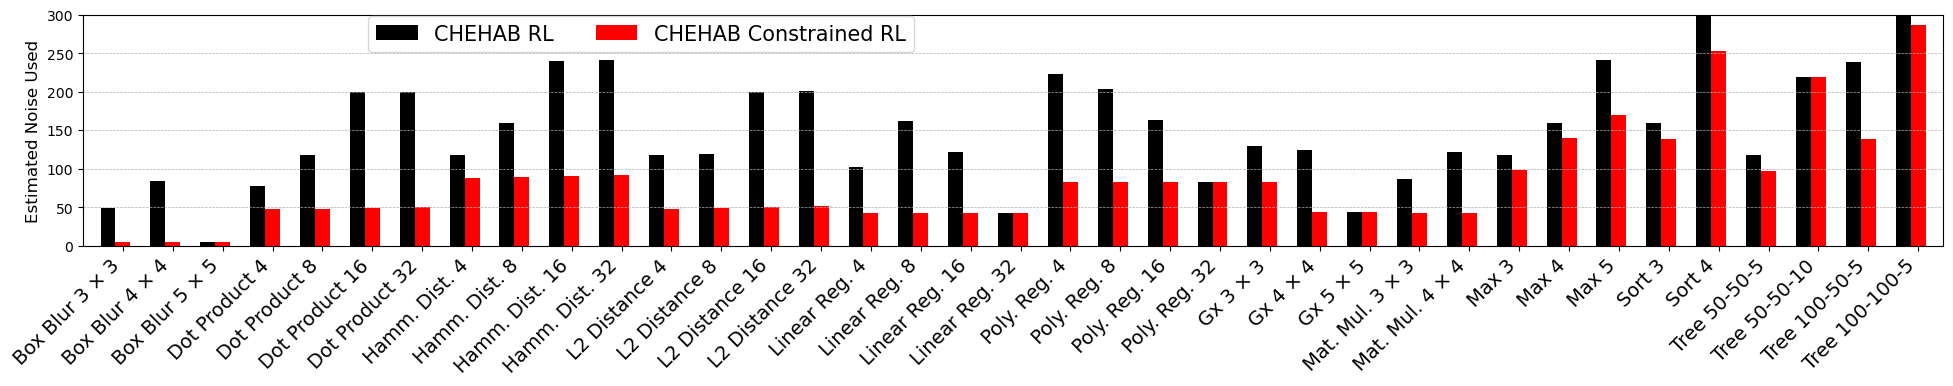

In [15]:
constrained_rl_noises_used = []
rl_noises_used = []
for benchmark in benchmarks : 
    benchmark_name = chehab_benchmarks_map[benchmark]

    if (noise := constrained_rl_name_to_estimated_noise_used.get(benchmark_name)) is not None:
        constrained_rl_noises_used.append(noise)
    else:
        print("not found", benchmark)
        constrained_rl_noises_used.append(0)

    if (noise := rl_name_to_estimated_noise_used.get(benchmark_name)) is not None:
        rl_noises_used.append(noise)
    else:
        print("not found", benchmark)
        rl_noises_used.append(0)

times = {
    "CHEHAB RL": np.array(rl_noises_used),
    "CHEHAB Constrained RL": np.array(constrained_rl_noises_used),
}
labels = ["CHEHAB RL", "CHEHAB Constrained RL"]
colors = ['Black', 'Red']
plot_estimated_noise_used_histogram(benchmarks, times, labels, colors)

# Ablation Studies

In [16]:
dfs = {
    "constrained_rl_od_ov": pd.read_excel(constrained_rl_ablation_od_ov_file),
    "constrained_rl_ov": pd.read_excel(constrained_rl_ablation_ov_file),
    "constrained_rl_od": pd.read_excel(constrained_rl_ablation_od_file),
    "constrained_rl": pd.read_excel(constrained_rl_ablation_file),
}

data = {}
for name, df in dfs.items():
    data[name] = {}
    for _, row in df.iterrows():
        benchmark = row["Name"]
        if benchmark not in data[name]:
            data[name][benchmark] = {}
        data[name][benchmark]["noise"] = row["Final Noise Used"]
        data[name][benchmark]["cost"] = row["Final Cost"]

In [17]:
def plot_noise_histogram(benchmarks, times, labels, colors, timeout_value=7200):
    num_benchmarks = len(benchmarks)
    x = np.arange(num_benchmarks)
    width = 0.3

    fig, ax = plt.subplots(figsize=(24, 3))
    hatch_color = (0.6, 0.6, 0.6, 1.0)
    linewidth = 4.0

    for i, label in enumerate(labels):
        adjusted_times = [timeout_value if t == float('inf') else min(t, timeout_value) for t in times[label]]
        hatch_patterns = ['//' if t == timeout_value and original_t == float('inf') else '' for t, original_t in zip(adjusted_times, times[label])]
        bars = ax.bar(x + i * width, adjusted_times, width, label=label, color=colors[i])
        for bar, hatch in zip(bars, hatch_patterns):
            if hatch:
                bar.set_hatch(hatch)
                bar._hatch_color = hatch_color
                bar._hatch_linewidth = linewidth

    ax.set_xticks(x + width * (len(labels) / 2))
    ax.set_xticklabels(benchmarks, rotation=45, ha="right", fontsize=14)
    ax.set_ylabel("Estimated Noise", fontsize=12)

    bar._hatch_color = hatch_color
    bar._hatch_linewidth = linewidth

    ax.legend(fontsize=15, loc="upper center", bbox_to_anchor=(0.30, 1.04), ncol=3)
    plt.xlim(-0.5, len(x) - 0.2)
    plt.ylim(auto=True)
    plt.grid(axis='y', linestyle="--", linewidth=0.5, which='major')

    plt.show()


In [18]:
def plot_cost_histogram(benchmarks, times, labels, colors, timeout_value=7200):
    num_benchmarks = len(benchmarks)
    x = np.arange(num_benchmarks)
    width = 0.3

    fig, ax = plt.subplots(figsize=(24, 3))
    hatch_color = (0.6, 0.6, 0.6, 1.0)
    linewidth = 4.0

    for i, label in enumerate(labels):
        adjusted_times = [timeout_value if t == float('inf') else min(t, timeout_value) for t in times[label]]
        hatch_patterns = ['//' if t == timeout_value and original_t == float('inf') else '' for t, original_t in zip(adjusted_times, times[label])]
        bars = ax.bar(x + i * width, adjusted_times, width, label=label, color=colors[i])
        for bar, hatch in zip(bars, hatch_patterns):
            if hatch:
                bar.set_hatch(hatch)
                bar._hatch_color = hatch_color
                bar._hatch_linewidth = linewidth

    ax.set_xticks(x + width * (len(labels) / 2))
    ax.set_xticklabels(benchmarks, rotation=45, ha="right", fontsize=14)
    ax.set_ylabel("Estimated Cost", fontsize=12)

    bar._hatch_color = hatch_color
    bar._hatch_linewidth = linewidth

    ax.legend(fontsize=15, loc="upper center", bbox_to_anchor=(0.30, 1.04), ncol=3)
    plt.xlim(-0.5, len(x) - 0.2)
    plt.ylim(auto=True)
    plt.grid(axis='y', linestyle="--", linewidth=0.5, which='major')

    plt.show()


In [19]:

def plot_ablation_study(first: str, second: str, metric: str):
    first_data = data.get(first, {})
    second_data = data.get(second, {})

    first_results = []
    second_results = []

    for benchmark in benchmarks : 
        benchmark_name = chehab_benchmarks_map[benchmark]

        if (result := first_data.get(benchmark_name, {}).get(metric)) is not None:
            first_results.append(result)
        else:
            print("not found", benchmark)
            first_results.append(0)

        if (result := second_data.get(benchmark_name, {}).get(metric)) is not None:
            second_results.append(result)
        else:
            print("not found", benchmark)
            second_results.append(0)

    times = {
        first: np.array(first_results),
        second: np.array(second_results),
    }
    labels = [first, second]
    colors = ['Black', 'Red']

    plot_histogram = None
    if metric == "noise":
        plot_histogram = plot_noise_histogram
    elif metric == "cost":
        plot_histogram = plot_cost_histogram
    plot_histogram(benchmarks, times, labels, colors)

## `constrained_rl` vs `constrained_rl_od`

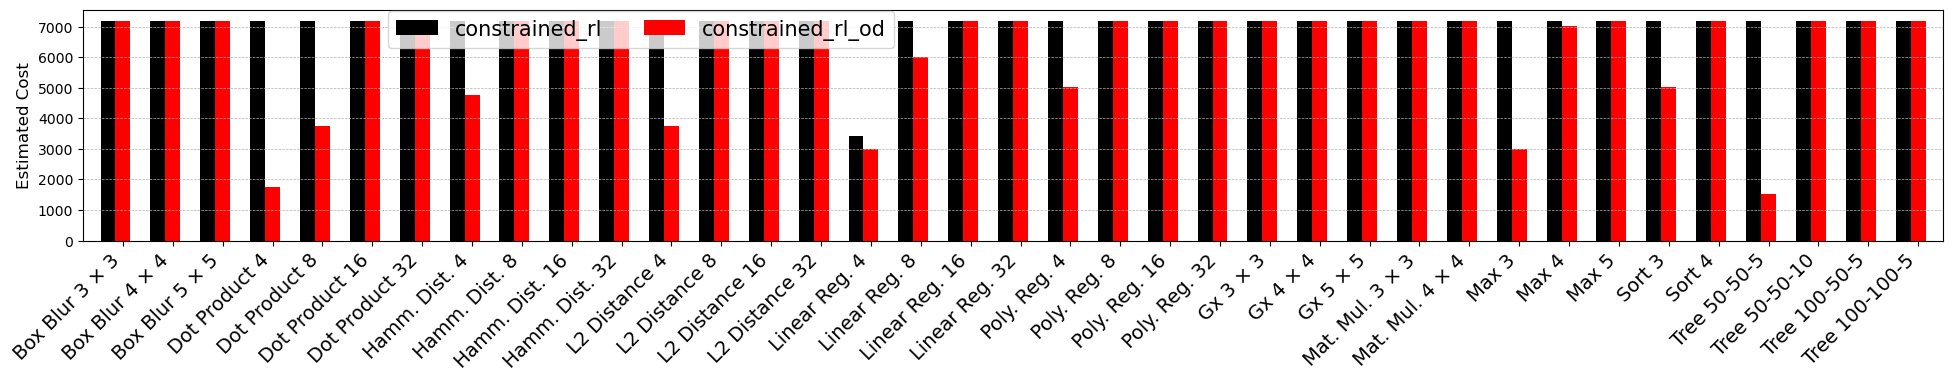

In [20]:
plot_ablation_study("constrained_rl", "constrained_rl_od", "cost")

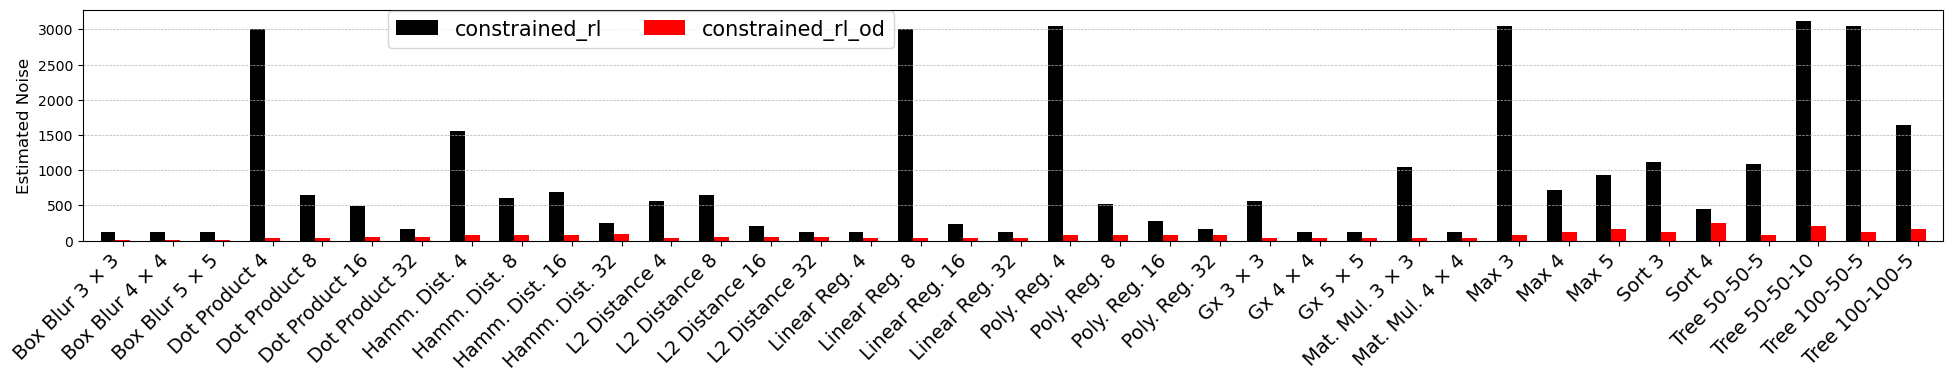

In [21]:
plot_ablation_study("constrained_rl", "constrained_rl_od", "noise")

## `constrained_rl` vs `constrained_rl_ov`

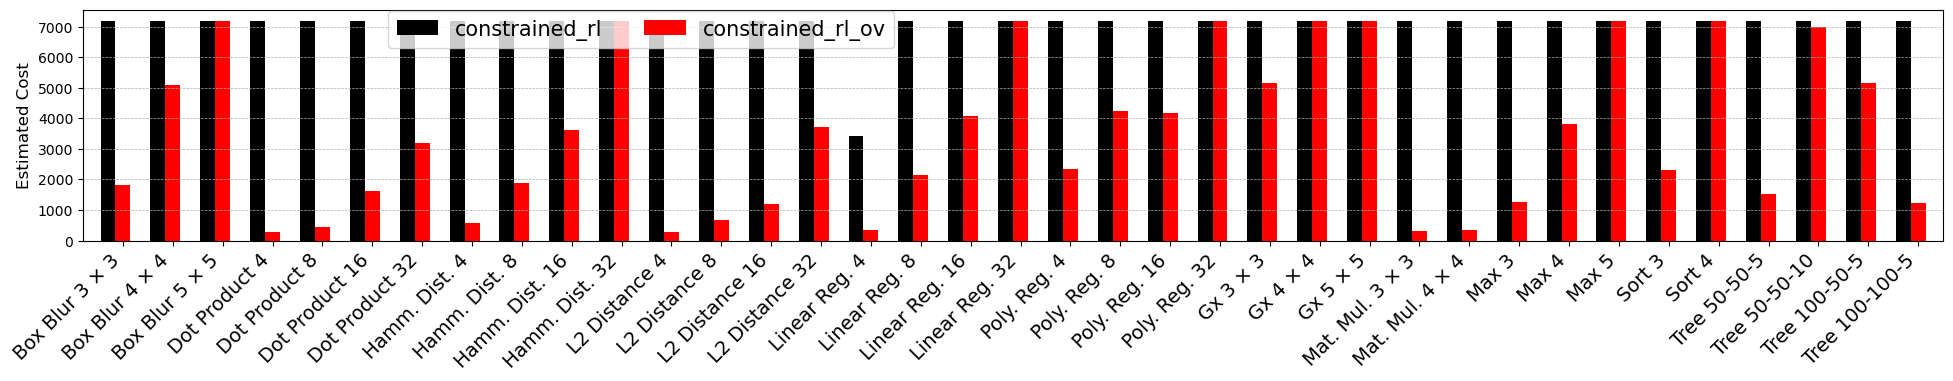

In [22]:
plot_ablation_study("constrained_rl", "constrained_rl_ov", "cost")

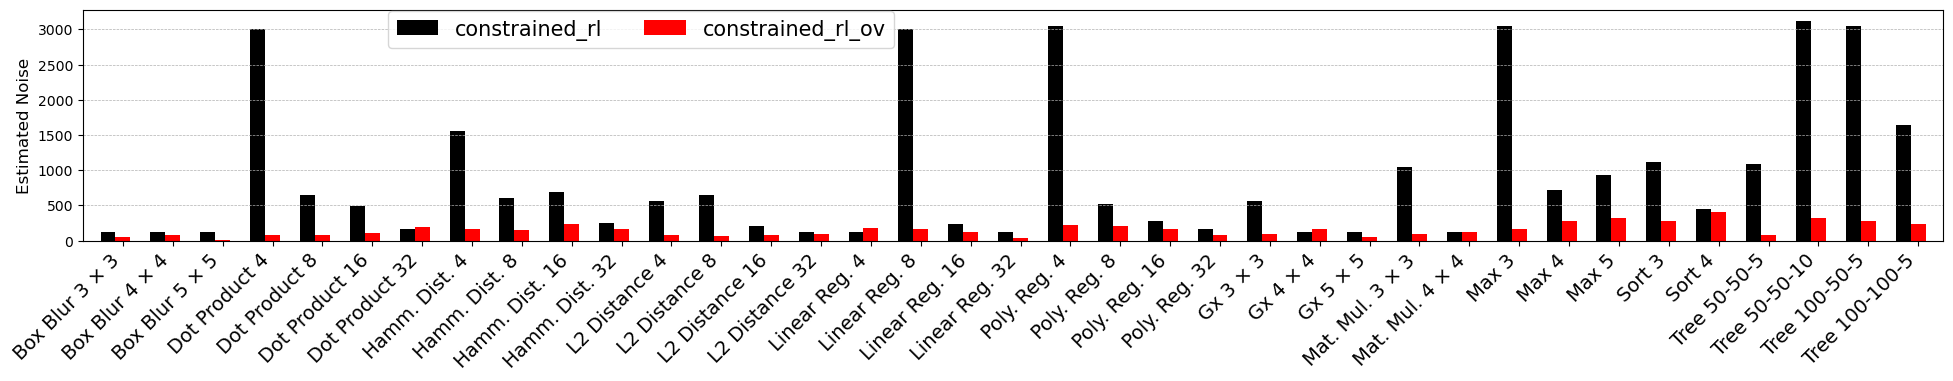

In [23]:
plot_ablation_study("constrained_rl", "constrained_rl_ov", "noise")

## `constrained_rl` vs `constrained_rl_od_ov`

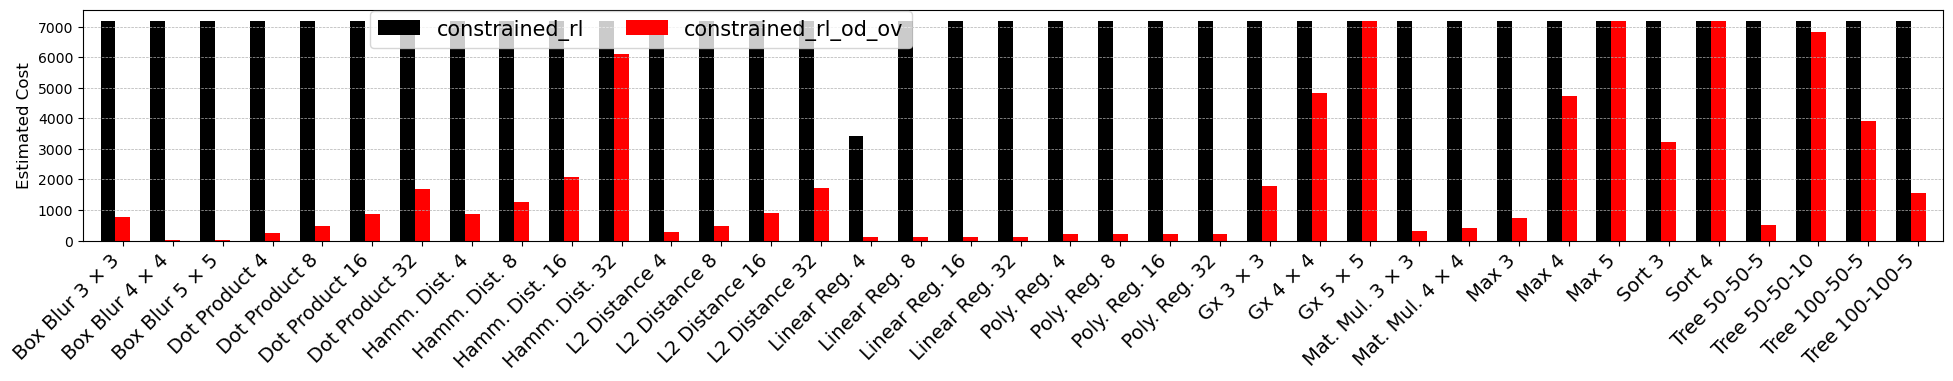

In [24]:
plot_ablation_study("constrained_rl", "constrained_rl_od_ov", "cost")

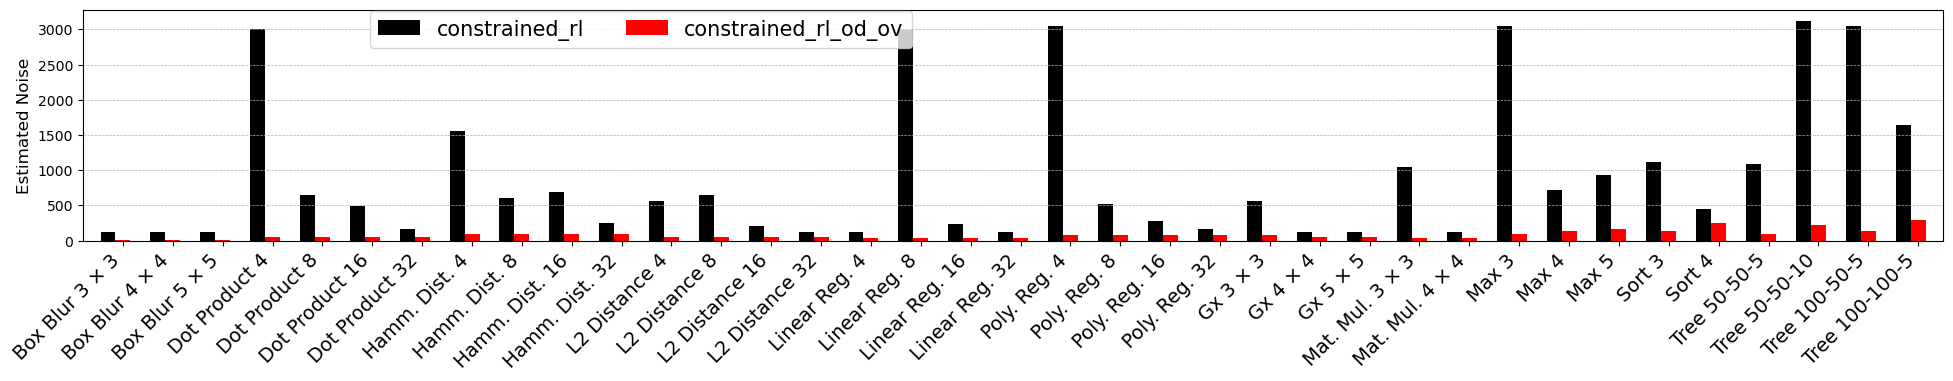

In [25]:
plot_ablation_study("constrained_rl", "constrained_rl_od_ov", "noise")

## `constrained_rl_ov` vs `constrained_rl_od_ov`

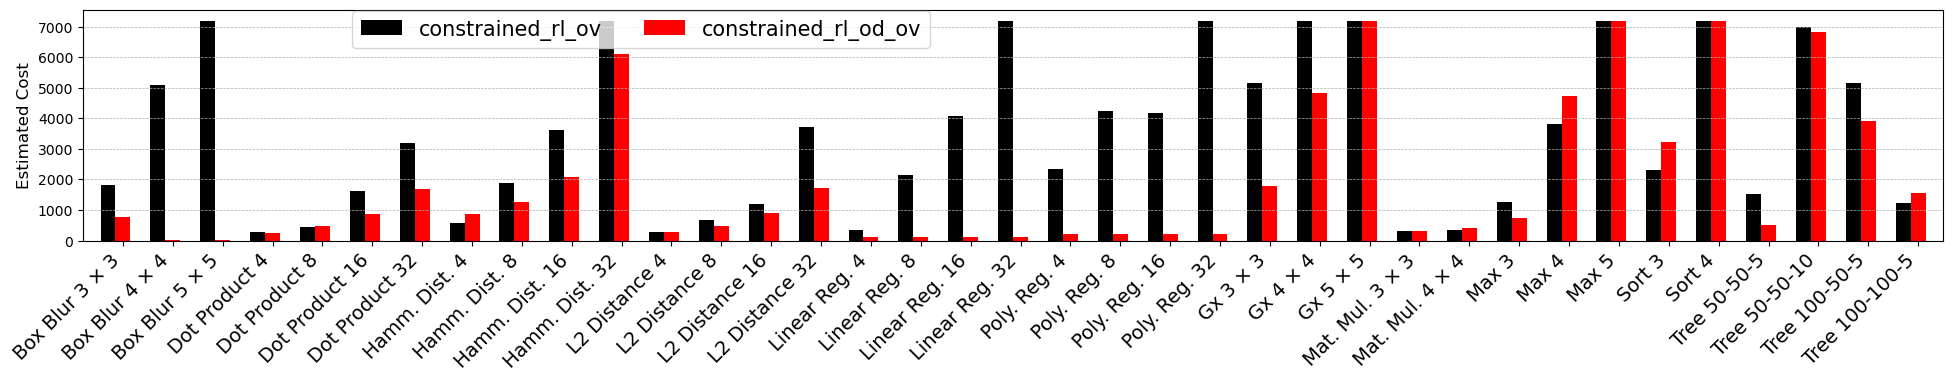

In [26]:
plot_ablation_study("constrained_rl_ov", "constrained_rl_od_ov", "cost")

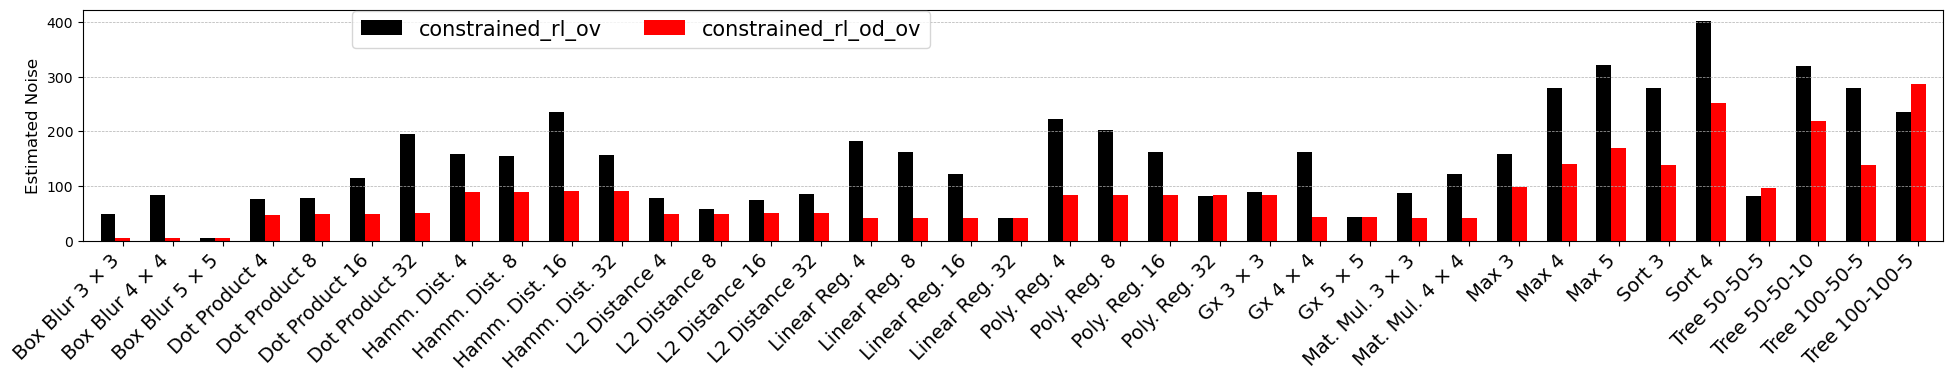

In [27]:
plot_ablation_study("constrained_rl_ov", "constrained_rl_od_ov", "noise")

## Best Agent : `constrained_rl_od_ov`

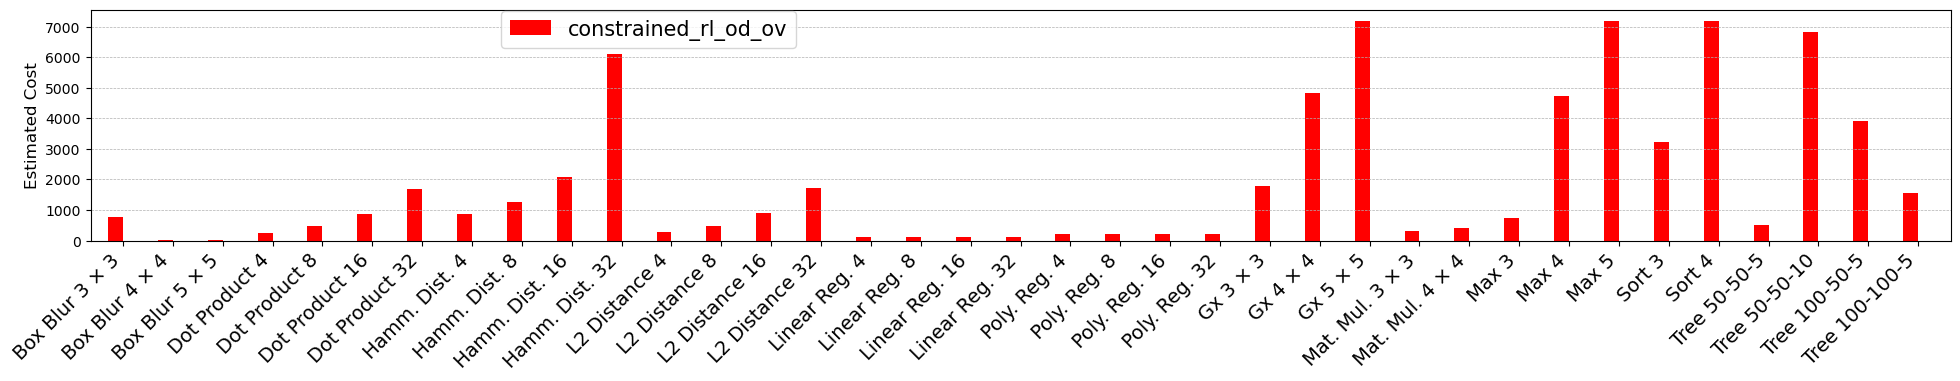

In [28]:
results = []
for benchmark in benchmarks : 
    benchmark_name = chehab_benchmarks_map[benchmark]
    result = data.get("constrained_rl_od_ov", {}).get(benchmark_name, {}).get("cost")
    results.append(result if result is not None else 0)
times = {"constrained_rl_od_ov": np.array(results)}
labels = ["constrained_rl_od_ov"]
colors = ['Red']
plot_cost_histogram(benchmarks, times, labels, colors)

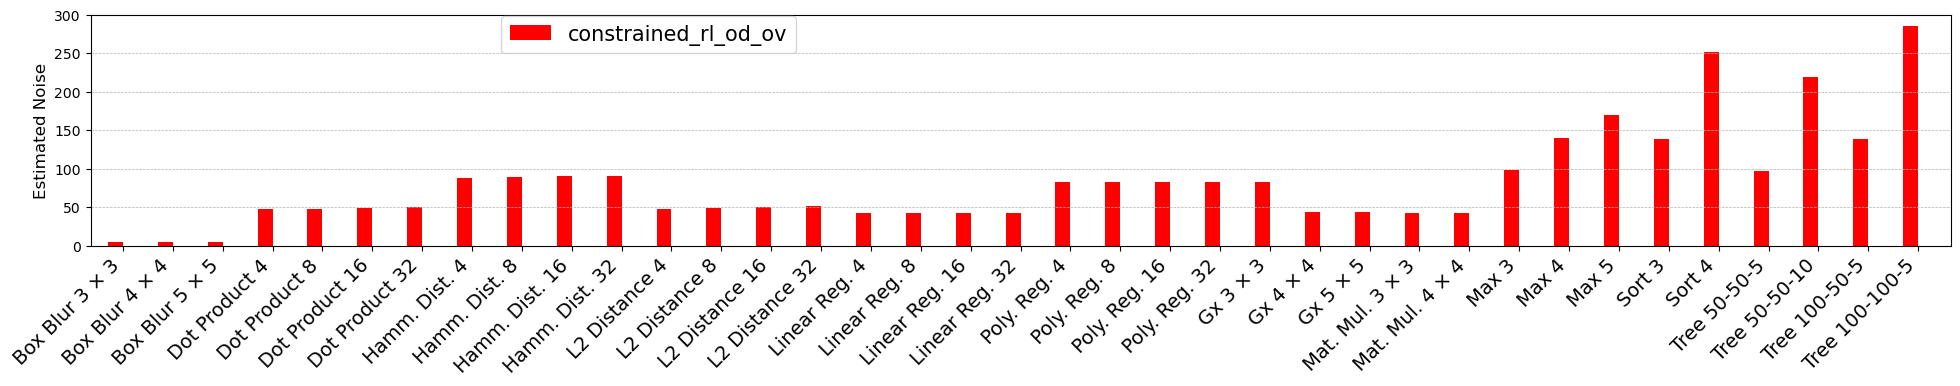

In [29]:
results = []
for benchmark in benchmarks : 
    benchmark_name = chehab_benchmarks_map[benchmark]
    result = data.get("constrained_rl_od_ov", {}).get(benchmark_name, {}).get("noise")
    results.append(result if result is not None else 0)
times = {"constrained_rl_od_ov": np.array(results)}
labels = ["constrained_rl_od_ov"]
colors = ['Red']
plot_noise_histogram(benchmarks, times, labels, colors)

# Linear Noise Estimator Results

## Plot Execution Times

/tmp/ipykernel_12908/593532138.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2*10**3)


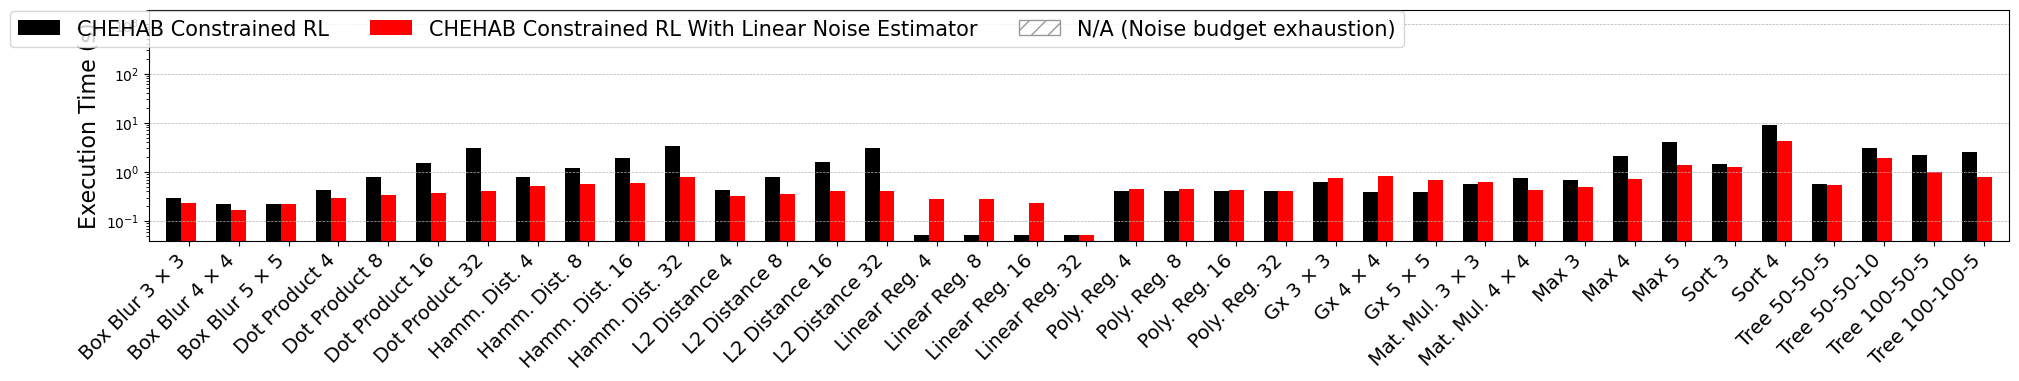

In [30]:
########################################################################################################
####################Load results #######################################################################
constrained_rl_rows = []
constrained_rl_with_linear_noise_estimator_rows = []
with open(constrained_rl_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    constrained_rl_rows = list(reader)
###########################################
with open(constrained_rl_with_linear_noise_estimator_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    constrained_rl_with_linear_noise_estimator_rows = list(reader)
#######################################################################################################
#######################################################################################################
constrained_rl_execution_times = []
constrained_rl_with_linear_noise_estimator_execution_times = []
for benchmark in benchmarks : 
    found = False
    for row in constrained_rl_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] :
            if len(row) > 1 :
                try : 
                    exec_time = float(row[10])
                except : 
                    exec_time = float('inf') 
                constrained_rl_execution_times.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        print("not found", benchmark)
        constrained_rl_execution_times.append(0)
    #####################################################
    found = False
    for row in constrained_rl_with_linear_noise_estimator_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] : 
            if len(row) > 1 :
                try : 
                    exec_time = float(row[10])
                except : 
                    exec_time = float('inf')
                constrained_rl_with_linear_noise_estimator_execution_times.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        constrained_rl_with_linear_noise_estimator_execution_times.append(0)

times = {
    "CHEHAB Constrained RL": np.array(constrained_rl_execution_times),
    "CHEHAB Constrained RL With Linear Noise Estimator": np.array(constrained_rl_with_linear_noise_estimator_execution_times),
}
labels = ["CHEHAB Constrained RL", "CHEHAB Constrained RL With Linear Noise Estimator"]
colors = ['Black', 'Red']
plot_execution_time_histogram(benchmarks, times, labels, colors)


## Plot Actual Noise Used

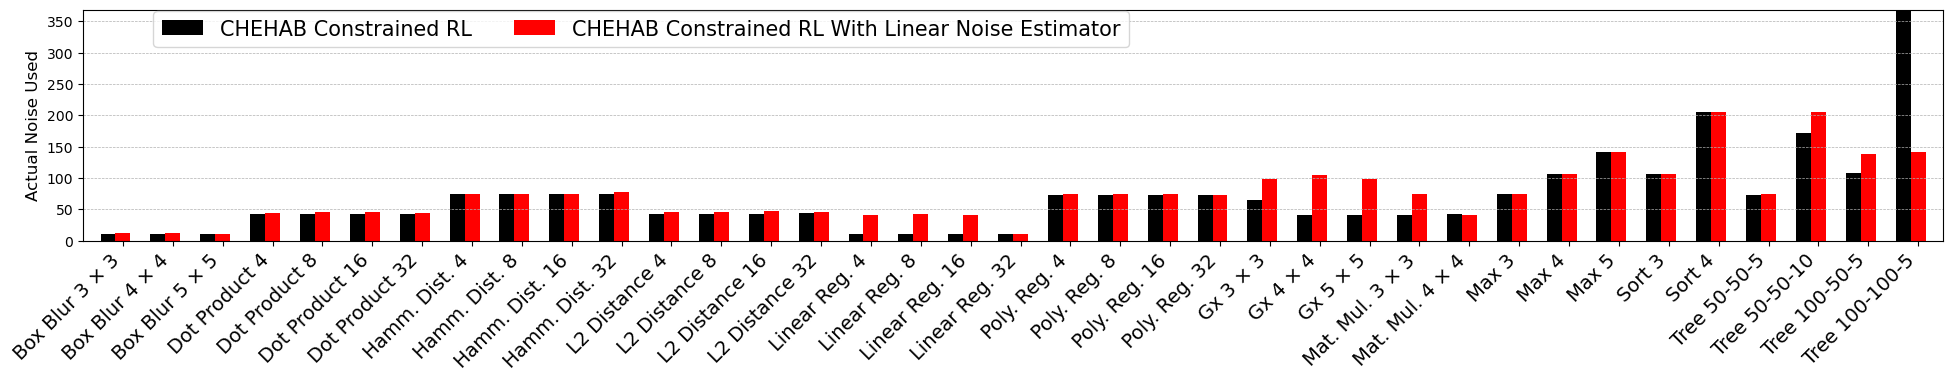

In [31]:
########################################################################################################
####################Load results #######################################################################
constrained_rl_rows = []
constrained_rl_with_linear_noise_estimator_rows = []
with open(constrained_rl_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    constrained_rl_rows = list(reader)
###########################################
with open(constrained_rl_with_linear_noise_estimator_results_file, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    headers = next(reader)
    constrained_rl_with_linear_noise_estimator_rows = list(reader)
#######################################################################################################
#######################################################################################################
constrained_rl_noises_used = []
constrained_rl_with_linear_noise_estimator_noises_used = []
for benchmark in benchmarks : 
    found = False
    for row in constrained_rl_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] :
            if len(row) > 1 :
                try : 
                    exec_time = 369 -  float(row[11])
                except : 
                    exec_time = float('inf') 
                constrained_rl_noises_used.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        print("not found", benchmark)
        constrained_rl_noises_used.append(0)
    #####################################################
    found = False
    for row in constrained_rl_with_linear_noise_estimator_rows :
        if row[0] ==  chehab_benchmarks_map[benchmark] : 
            if len(row) > 1 :
                try : 
                    exec_time = 369 - float(row[11])
                except : 
                    exec_time = float('inf')
                constrained_rl_with_linear_noise_estimator_noises_used.append(exec_time)
                found= True
                break
            else : 
                break
    if not found : 
        constrained_rl_with_linear_noise_estimator_noises_used.append(0)

times = {
    "CHEHAB Constrained RL": np.array(constrained_rl_noises_used),
    "CHEHAB Constrained RL With Linear Noise Estimator": np.array(constrained_rl_with_linear_noise_estimator_noises_used),
}
labels = ["CHEHAB Constrained RL", "CHEHAB Constrained RL With Linear Noise Estimator"]
colors = ['Black', 'Red']
plot_actual_noise_used_histogram(benchmarks, times, labels, colors)

## Plot Estimated Noise Used

In [32]:
constrained_rl_estimated_noises_used = pd.read_excel(constrained_rl_ablation_od_ov_file)
constrained_rl_with_linear_noise_estimator_estimated_noises_used = pd.read_excel(constrained_rl_ablation_od_ov_with_linear_noise_estimator_file)

constrained_rl_name_to_estimated_noise_used = dict(zip(
    constrained_rl_estimated_noises_used["Name"].to_numpy(), 
    constrained_rl_estimated_noises_used["Final Noise Used"].to_numpy(),
))

constrained_rl_with_linear_noise_estimator_name_to_estimated_noise_used = dict(zip(
    constrained_rl_with_linear_noise_estimator_estimated_noises_used["Name"].to_numpy(), 
    constrained_rl_with_linear_noise_estimator_estimated_noises_used["Final Noise Used"].to_numpy(),
))

not found Dot Product 8


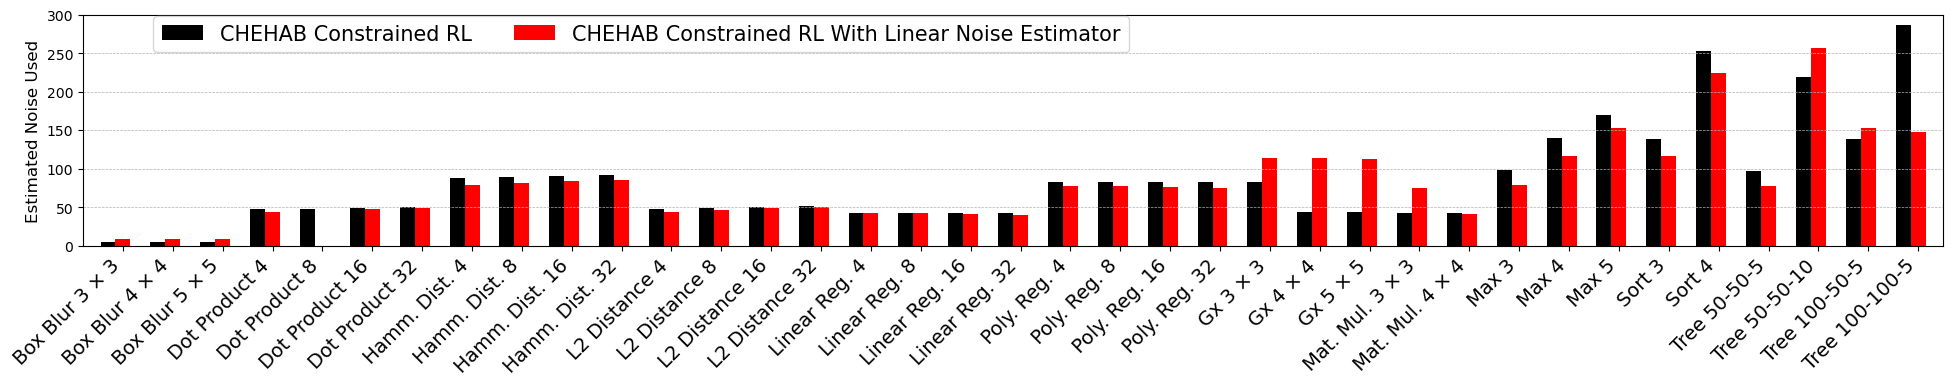

In [33]:
constrained_rl_noises_used = []
constrained_rl_with_linear_noise_estimator_noises_used = []
for benchmark in benchmarks : 
    benchmark_name = chehab_benchmarks_map[benchmark]

    if (noise := constrained_rl_name_to_estimated_noise_used.get(benchmark_name)) is not None:
        constrained_rl_noises_used.append(noise)
    else:
        print("not found", benchmark)
        constrained_rl_noises_used.append(0)

    if (noise := constrained_rl_with_linear_noise_estimator_name_to_estimated_noise_used.get(benchmark_name)) is not None:
        constrained_rl_with_linear_noise_estimator_noises_used.append(noise)
    else:
        print("not found", benchmark)
        constrained_rl_with_linear_noise_estimator_noises_used.append(0)

times = {
    "CHEHAB Constrained RL": np.array(constrained_rl_noises_used),
    "CHEHAB Constrained RL With Linear Noise Estimator": np.array(constrained_rl_with_linear_noise_estimator_noises_used),
}
labels = ["CHEHAB Constrained RL", "CHEHAB Constrained RL With Linear Noise Estimator"]
colors = ['Black', 'Red']
plot_estimated_noise_used_histogram(benchmarks, times, labels, colors)